In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df= pd.read_csv(r"/root/Cyber/Cyber_security/datasets/02-14-2018_uncleaned.csv")

Model achieved near perfect accuracy , doesnt seem to viable probably an overfit for the most part will check corr and see the features to drop

In [4]:
corr_test=df.drop(columns=["Label"])

In [5]:
corr = corr_test.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
to_drop

['TotLen_Bwd_Pkts',
 'Fwd_Pkt_Len_Std',
 'Bwd_Pkt_Len_Std',
 'Flow_IAT_Min',
 'Fwd_IAT_Tot',
 'Fwd_IAT_Mean',
 'Fwd_IAT_Max',
 'Fwd_IAT_Min',
 'Fwd_Header_Len',
 'Bwd_Header_Len',
 'Fwd_Pkts/s',
 'Bwd_Pkts/s',
 'Pkt_Len_Min',
 'Pkt_Len_Max',
 'Pkt_Len_Mean',
 'Pkt_Len_Std',
 'Pkt_Size_Avg',
 'Fwd_Seg_Size_Avg',
 'Bwd_Seg_Size_Avg',
 'Subflow_Fwd_Pkts',
 'Subflow_Fwd_Byts',
 'Subflow_Bwd_Pkts',
 'Subflow_Bwd_Byts',
 'Active_Min',
 'Idle_Max',
 'Idle_Min']

In [60]:
selected_features = [

    "Tot_Fwd_Pkts",
    "Tot_Bwd_Pkts",
    "TotLen_Fwd_Pkts",
    "TotLen_Bwd_Pkts",

    "Fwd_Pkt_Len_Max",
    "Bwd_Pkt_Len_Max",
    "Pkt_Len_Mean",
    "Pkt_Len_Std",

    "Flow_IAT_Mean",
    "Flow_IAT_Std",
    "Fwd_IAT_Mean",
    "Bwd_IAT_Mean",

    "Down/Up_Ratio",

    "Fwd_Act_Data_Pkts",

    "Active_Mean",
    "Active_Std",
    "Idle_Mean",
    "Idle_Std",
    "Label"
]
feature_selected_dataset=df[selected_features]

In [61]:
feature_selected_dataset.columns.shape

(19,)

In [62]:
feature_selected_dataset["Label"].unique()

array(['benign', 'bruteforce', 'ssh-bruteforce'], dtype=object)

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [64]:
X=feature_selected_dataset.drop(columns=["Label"])
y=feature_selected_dataset["Label"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape,y_train.shape)

(835952, 18) (835952,)


In [65]:
rf=RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
target_names=['benign','bruteforce','ssh-bruteforce']
y_pred=rf.predict(X_test)
print(classification_report(y_test,y_pred,target_names=target_names))

                precision    recall  f1-score   support

        benign       1.00      0.98      0.99    132799
    bruteforce       0.91      0.98      0.95     38671
ssh-bruteforce       0.97      0.97      0.97     37518

      accuracy                           0.98    208988
     macro avg       0.96      0.98      0.97    208988
  weighted avg       0.98      0.98      0.98    208988



In [67]:
rf.feature_names_in_

array(['Tot_Fwd_Pkts', 'Tot_Bwd_Pkts', 'TotLen_Fwd_Pkts',
       'TotLen_Bwd_Pkts', 'Fwd_Pkt_Len_Max', 'Bwd_Pkt_Len_Max',
       'Pkt_Len_Mean', 'Pkt_Len_Std', 'Flow_IAT_Mean', 'Flow_IAT_Std',
       'Fwd_IAT_Mean', 'Bwd_IAT_Mean', 'Down/Up_Ratio',
       'Fwd_Act_Data_Pkts', 'Active_Mean', 'Active_Std', 'Idle_Mean',
       'Idle_Std'], dtype=object)

In [68]:
rf.feature_importances_

array([8.07082880e-02, 6.02761570e-02, 8.43936289e-02, 2.73381209e-02,
       6.35397426e-02, 1.23074305e-02, 7.21167871e-02, 3.52487204e-02,
       3.90820964e-01, 1.65527699e-02, 5.10704539e-02, 4.42764692e-03,
       2.05001842e-02, 7.87944304e-02, 6.75734824e-04, 9.76961346e-05,
       7.47144214e-04, 3.84099968e-04])

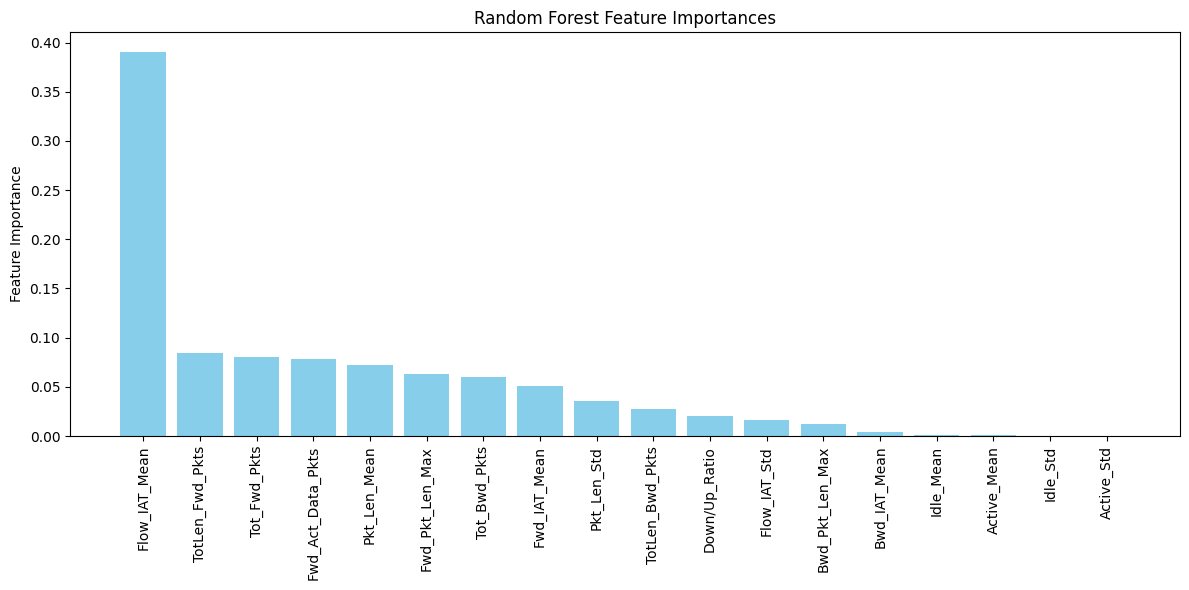

In [69]:
importances = rf.feature_importances_
features = rf.feature_names_in_

indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = features[indices]

plt.figure(figsize=(12, 6))
plt.bar(range(len(sorted_features)), sorted_importances, color='skyblue')
plt.xticks(range(len(sorted_features)), sorted_features, rotation=90)
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

I 